In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

ACTIVATIONS_ROOT = './activations/'
DATASET_ROOT = './datasets'

label_fontsize = 18

In [2]:
import torch

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [3]:
from src.spectral_cka import experiment
from src.power_law_utils import power_law_diag_matrix

File ./results/overlap_power_law_1000_trials_1_iters_10.npz does not exist. Running the experiment...
P=1000, N1=1000, N2=1000, True CKA: 1.0, True CCA: 1.0
Neuron_size=10/1000
371 3.635075529473397e-08
234 9.41314812763494e-08
204 3.8592760986944086e-08
356 3.7376135963995694e-08
554 9.667605205265772e-08
233 5.971532068826946e-08
231 7.211855823641145e-08
432 2.8699421505962164e-08
275 3.3285729728049773e-09
247 4.9651740496869934e-08


/mnt/home/acanatar/jupyter/spectral_cka/NeurIPS_camera_ready/code/src/spectral_cka.py:181: RuntimeWarning: invalid value encountered in sqrt
  y = x1 / np.sqrt(x2 * x3)
/mnt/home/acanatar/jupyter/spectral_cka/NeurIPS_camera_ready/code/src/spectral_cka.py:182: RuntimeWarning: invalid value encountered in sqrt
  sigma_y = np.sqrt(term1 + term2 + term3)


317 8.575467225213629e-08
Neuron_size=31/1000
310 7.702519866370494e-08
328 2.9878021834406354e-08
233 4.8182464240653644e-08
372 6.210042968746166e-08
317 2.5793676527996467e-08
331 8.972518728000978e-09
313 8.88447519997726e-08
326 5.2475758849368503e-08
179 9.330008943209123e-08
255 8.392896955200513e-08
272 3.90608150269145e-08
Neuron_size=100/1000
365 4.1050224552918735e-08
321 3.5270211640181515e-08
392 5.061320251797952e-10
350 5.820671056255833e-08
332 1.3321983516334512e-08
397 1.9561122499567318e-08
303 3.2398924432186504e-08
339 6.786105188893998e-08
238 1.7299715437957275e-08
264 4.283755838940806e-08
318 7.019915937434007e-08
Neuron_size=316/1000
281 8.118512972998815e-08
432 9.054165950317383e-08
439 9.699426151144053e-08
417 7.399856905010438e-08
454 9.060325822929371e-08
500 1.5046422774389612e-08
338 8.279548069367593e-08
366 6.030504451359775e-08
398 2.3956042483064266e-08
326 5.561883398286227e-08
276 1.0486445489732432e-08


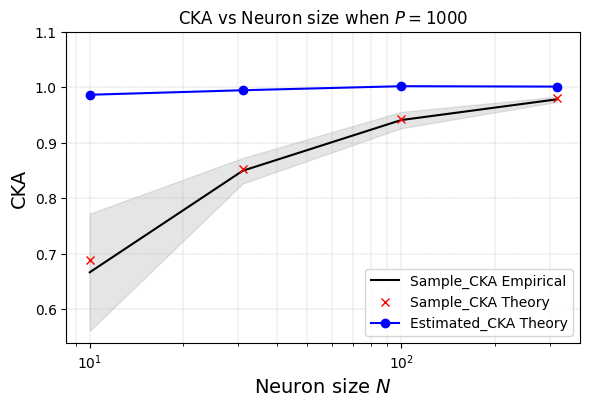

In [4]:
sample_sizes = np.logspace(1.61, 3, 3, dtype=int)
sample_sizes = [1000]
neuron_sizes = np.logspace(1, 2.5, 4, dtype=int)
num_trials = 1
num_iterations = 10
cutoff = 2000

exponent = 1.2

act = torch.sqrt(power_law_diag_matrix(1000, exponent, device=device))

use_real_neuron = False
override = False

all_data = experiment(act,
                      act,
                      sample_sizes,
                      neuron_sizes,
                      num_trials=num_trials,
                      num_iterations=num_iterations,
                      cutoff=cutoff,
                      use_real_neuron=use_real_neuron,
                      fn_prefix='overlap_power_law',
                      fn_suffix='',
                      override=override)

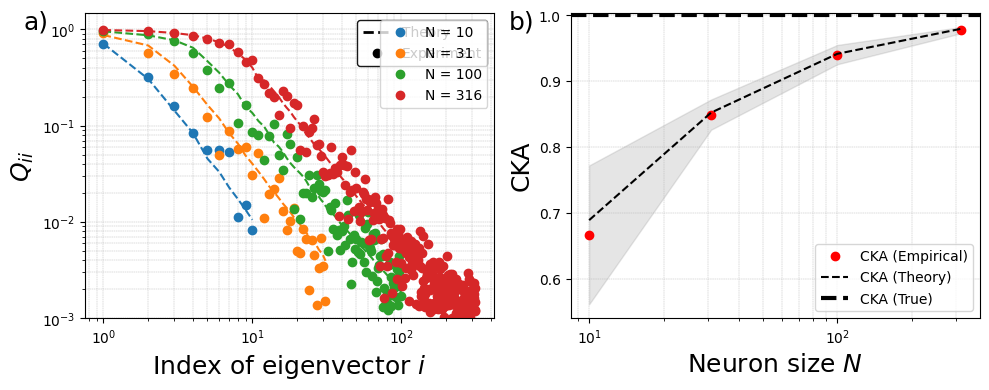

In [5]:
from matplotlib.lines import Line2D

keys = ['naive_cka_final', 'predicted_cka_final', 'estimated_cka_final', 'cka_naive_mean', 'cka_naive_std',
        'Q_emp_mean', 'Q_emp_std', 'Q_th_mean', 'Q_th_std', 'Q_th_final']

total_data = {key: [] for key in keys}
for data in all_data:
    for key in keys:
        total_data[key] += [data[key]]
total_data = {key: np.asarray(total_data[key]) for key in keys}

filter_cutoff = None
P_idx = -1
skip = 1

cka_mean = total_data['cka_naive_mean'].mean(-1)[P_idx]
cka_std = total_data['cka_naive_std'].mean(-1)[P_idx]
predicted_cka = total_data['predicted_cka_final'].mean(-1)[P_idx]
estimated_cka = total_data['estimated_cka_final'].mean(-1)[P_idx]
Q_emp_mean = total_data['Q_emp_mean'].mean(-1)
Q_th_mean = total_data['Q_th_mean'].mean(-1)
Q_th_avg = total_data['Q_th_final'].mean(-1)

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - CKA plot
ax1.semilogx(neuron_sizes, cka_mean, 'o', label='CKA (Empirical)', color='red')
ax1.fill_between(neuron_sizes, cka_mean - cka_std, cka_mean + cka_std, color='gray', alpha=0.2)
ax1.semilogx(neuron_sizes, predicted_cka, '--', label='CKA (Theory)', color='black')
ax1.axhline(y=1, color='black', linestyle='dashed', linewidth=3, label='CKA (True)')
ax1.set_xlabel(r"Neuron size $N$", fontsize=label_fontsize)
ax1.set_ylabel(r"CKA", fontsize=label_fontsize)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
ax1.legend(loc='lower right', fontsize=10)

# Second subplot - Q diagonal elements
for i, idx in enumerate(range(0, len(neuron_sizes), skip)):
    Q_emp = Q_emp_mean[P_idx, idx, :, :]
    Q_th = Q_th_avg[P_idx, idx, :, :]
    N = neuron_sizes[idx]
    idxs = np.arange(1, len(Q_emp)+1)
    ax2.loglog(idxs[:N], np.diag(Q_emp)[:N], 'o', label=f'N = {N}', color=f'C{i}')
    ax2.loglog(idxs[:N], np.diag(Q_th)[:N], '--', color=f'C{i}')

linestyle_legend = [Line2D([0], [0], color='black', marker=None, linestyle='--', label=f"Theory", lw=2),
                    Line2D([0], [0], color='black', marker='o', linestyle="None", label=f"Experiment", lw=2)]
first_legend = ax2.legend(handles=linestyle_legend, loc='upper right', fontsize=10,
                          frameon=True, framealpha=0.9, edgecolor='black', fancybox=True)
ax2.add_artist(first_legend)
ax2.set_xlabel('Index of eigenvector $i$', fontsize=label_fontsize)
ax2.set_ylabel(r'$Q_{ii}$', fontsize=label_fontsize)
ax2.set_ylim([1e-3, None])
ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', linewidth=0.3)

plt.tight_layout()
ax1.text(-0.15, 0.95, 'b)', fontsize=18, transform=ax1.transAxes)
ax2.text(-0.15, 0.95, 'a)', fontsize=18, transform=ax2.transAxes)
# plt.savefig('./figures/overlap_and_cka_powerlaw.pdf', bbox_inches='tight')
plt.show()

In [6]:
from src.power_law_utils import power_law_theory, infer_power_law_exponent, sample_power_law_matrix

In [7]:
P = 1000
N = 100
exponent = 1.1

eigs2 = power_law_theory(P, N, exponent)

infer_power_law_exponent(eigs2, N=N, cutoff=N)

array([1.10000001])

In [8]:
P = 800
exp = 0.99
N_list = [25, 50, 75, 100, 150, 200, 500, 1000]

eigs_list = []
eigs_th_list = []
infer_list = []

for N in N_list:
    eigs = 0
    num_trials = 200

    for _ in range(num_trials):
        act, cov = sample_power_law_matrix(P, N, exp, device=device)
        eig, vec = torch.linalg.eigh(act)
        eigs += eig.cpu().numpy()[::-1]/num_trials

    eigs_th = power_law_theory(P, N, exp)
    infer = infer_power_law_exponent(eigs, N=N)

    eigs_list.append(eigs)
    eigs_th_list.append(eigs_th)
    infer_list.append(infer)

    print(infer)

eigs_list = np.asarray(eigs_list)
eigs_th_list = np.asarray(eigs_th_list)
infer_list = np.asarray(infer_list)

[1.03565598]
[1.01372396]
[1.00522513]
[1.00067917]
[1.00002724]
[1.00000294]
[1.00004268]
[1.00003378]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


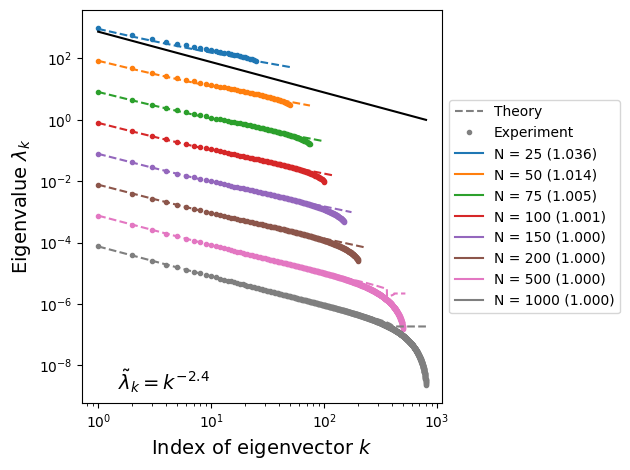

In [9]:
from matplotlib.lines import Line2D

for n, (eigs, eigs_th, infer) in enumerate(zip(eigs_list, eigs_th_list, infer_list)):

    mag = 10**-n
    # mag = 1

    eig = eigs[:N_list[n]]
    k = np.arange(1, len(eig)+1)
    plt.loglog(k, eig*mag, '.', color=f'C{n}')

    eig_th = eigs_th[:N_list[n]+25]
    k = np.arange(1, len(eig_th)+1)
    plt.semilogx(k, eig_th*mag, '--', color=f'C{n}')

k = np.arange(1, len(cov)+1)
plt.plot(k, cov, color='black')

plt.xlabel('Index of eigenvector $k$', fontsize=14)
plt.ylabel('Eigenvalue $\lambda_k$', fontsize=14)

custom_lines = [Line2D([0], [0], linestyle='--', color='gray'),
                Line2D([0], [0], marker='.', color='gray', linestyle='none')]
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Show N={N_list} labels
plt.legend(custom_lines + [Line2D([0], [0], color=f'C{i}') for i in range(len(N_list))],
           ['Theory', 'Experiment'] + [f'N = {N} ({infer[0]:.3f})' for N, infer in zip(N_list, infer_list)],
           loc='center left', bbox_to_anchor=(1, 0.5))

plt.text(0.1, 0.02, '$\\tilde\lambda_k = k^{-2.4}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='bottom')


plt.tight_layout()
# plt.savefig('./figures/power_law_prediction.pdf', bbox_inches='tight')